In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/"
    "Intrusion_Detection_System"
)

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("MODEL ANALYSIS AND IMPROVEMENT")
print("=" * 70)

print("Project :", PROJECT_DIR)
print("Dataset :", DATASET_DIR)
print("Models  :", MODELS_DIR)
print("Results :", RESULTS_DIR)

MODEL ANALYSIS AND IMPROVEMENT
Project : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System
Dataset : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned
Models  : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models
Results : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results


In [22]:
y_train = pd.read_parquet(
    DATASET_DIR / "y_train.parquet"
).squeeze()

y_train_smote = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

print("=" * 70)
print("LABEL DATA LOADED")
print("=" * 70)

print("Original y_train     :", y_train.shape)
print("SMOTE y_train        :", y_train_smote.shape)
print("y_test               :", y_test.shape)

LABEL DATA LOADED
Original y_train     : (1591936,)
SMOTE y_train        : (2563626,)
y_test               : (397985,)


In [23]:
original_counts = y_train.value_counts().sort_index()
smote_counts = y_train_smote.value_counts().sort_index()

smote_comparison = pd.DataFrame({
    "Original Training": original_counts,
    "After SMOTE": smote_counts
}).fillna(0)

smote_comparison["Increase"] = (
    smote_comparison["After SMOTE"]
    - smote_comparison["Original Training"]
)

smote_comparison["Increase %"] = (
    smote_comparison["Increase"]
    / smote_comparison["Original Training"]
    * 100
)

print("=" * 70)
print("SMOTE CLASS DISTRIBUTION")
print("=" * 70)

display(smote_comparison)

SMOTE CLASS DISTRIBUTION


,Original Training,After SMOTE,Increase,Increase %
Label,,,,
0,1323620,1323620,0,0.000000
1,1070,100000,98930,9245.794393
2,102413,102413,0,0.000000
3,8225,100000,91775,1115.805471
4,137593,137593,0,0.000000
5,4182,100000,95818,2291.200383
6,4308,100000,95692,2221.262767
7,4745,100000,95255,2007.481560
8,9,50000,49991,555455.555556


In [24]:
import joblib

label_encoder = joblib.load(
    MODELS_DIR / "label_encoder.pkl"
)

class_names = joblib.load(
    MODELS_DIR / "class_names.pkl"
)

print("=" * 70)
print("LABEL MAPPING")
print("=" * 70)

for label in sorted(smote_comparison.index):
    print(f"{label:2d} -> {class_names[int(label)]}")

LABEL MAPPING
 0 -> 0
 1 -> 1
 2 -> 2
 3 -> 3
 4 -> 4
 5 -> 5
 6 -> 6
 7 -> 7
 8 -> 8
 9 -> 9
10 -> 10
11 -> 11
12 -> 12
13 -> 13
14 -> 14


In [25]:
import joblib

label_encoder = joblib.load(
    MODELS_DIR / "label_encoder.pkl"
)

print("=" * 70)
print("ACTUAL LABEL ENCODER MAPPING")
print("=" * 70)

for label, class_name in enumerate(label_encoder.classes_):
    print(f"{label:2d} -> {class_name}")

ACTUAL LABEL ENCODER MAPPING
 0 -> BENIGN
 1 -> Bot
 2 -> DDoS
 3 -> DoS GoldenEye
 4 -> DoS Hulk
 5 -> DoS Slowhttptest
 6 -> DoS slowloris
 7 -> FTP-Patator
 8 -> Heartbleed
 9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack � Brute Force
13 -> Web Attack � Sql Injection
14 -> Web Attack � XSS


In [26]:
from pathlib import Path

print("=" * 70)
print("SEARCHING FOR STACKING PREDICTIONS")
print("=" * 70)

for file in RESULTS_DIR.rglob("*"):
    if file.is_file():
        if "stack" in file.name.lower() or "prediction" in file.name.lower():
            print(file)

SEARCHING FOR STACKING PREDICTIONS
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/Final_Stacking_Ensemble_Metrics.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/Final_Stacking_ConfusionMatrix.png


In [27]:
# Exact class names
class_names_actual = list(label_encoder.classes_)

# Add readable class names
analysis_df = smote_comparison.copy()

analysis_df.insert(
    0,
    "Class",
    [class_names_actual[int(i)] for i in analysis_df.index]
)

# Add test support
test_counts = y_test.value_counts().sort_index()

analysis_df["Test Support"] = test_counts

# Add the recall and F1 from our final stacking model
stacking_recall = {
    0: 1.00,
    1: 0.87,
    2: 1.00,
    3: 0.99,
    4: 0.99,
    5: 0.99,
    6: 0.99,
    7: 0.99,
    8: 1.00,
    9: 0.57,
    10: 0.93,
    11: 0.95,
    12: 0.59,
    13: 0.50,
    14: 0.48
}

stacking_f1 = {
    0: 1.00,
    1: 0.72,
    2: 1.00,
    3: 0.97,
    4: 0.99,
    5: 0.96,
    6: 0.99,
    7: 0.99,
    8: 1.00,
    9: 0.73,
    10: 0.91,
    11: 0.93,
    12: 0.63,
    13: 0.36,
    14: 0.34
}

analysis_df["Stacking Recall"] = [
    stacking_recall[int(i)] for i in analysis_df.index
]

analysis_df["Stacking F1"] = [
    stacking_f1[int(i)] for i in analysis_df.index
]

print("=" * 70)
print("COMPLETE CLASS-LEVEL ANALYSIS")
print("=" * 70)

display(
    analysis_df[
        [
            "Class",
            "Original Training",
            "After SMOTE",
            "Test Support",
            "Stacking Recall",
            "Stacking F1"
        ]
    ]
)

COMPLETE CLASS-LEVEL ANALYSIS


,Class,Original Training,After SMOTE,Test Support,Stacking Recall,Stacking F1
Label,,,,,,
0,BENIGN,1323620,1323620,330906,1.00,1.00
1,Bot,1070,100000,268,0.87,0.72
2,DDoS,102413,102413,25603,1.00,1.00
3,DoS GoldenEye,8225,100000,2056,0.99,0.97
4,DoS Hulk,137593,137593,34399,0.99,0.99
5,DoS Slowhttptest,4182,100000,1045,0.99,0.96
6,DoS slowloris,4308,100000,1077,0.99,0.99
7,FTP-Patator,4745,100000,1187,0.99,0.99
8,Heartbleed,9,50000,2,1.00,1.00


In [28]:
import joblib
import pandas as pd
import numpy as np
import time

print("=" * 70)
print("LOADING SAVED STACKING COMPONENTS")
print("=" * 70)

rf_model = joblib.load(
    MODELS_DIR / "random_forest_model.pkl"
)

et_model = joblib.load(
    MODELS_DIR / "extra_trees_model.pkl"
)

xgb_model = joblib.load(
    MODELS_DIR / "xgboost_model.pkl"
)

meta_learner = joblib.load(
    MODELS_DIR / "stacking_meta_learner.pkl"
)

label_encoder = joblib.load(
    MODELS_DIR / "label_encoder.pkl"
)

print("✓ Random Forest loaded")
print("✓ Extra Trees loaded")
print("✓ XGBoost loaded")
print("✓ Meta learner loaded")
print("✓ Label encoder loaded")

LOADING SAVED STACKING COMPONENTS
✓ Random Forest loaded
✓ Extra Trees loaded
✓ XGBoost loaded
✓ Meta learner loaded
✓ Label encoder loaded


In [29]:
X_test = pd.read_parquet(
    DATASET_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

print("=" * 70)
print("TEST DATA")
print("=" * 70)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

TEST DATA
X_test : (397985, 30)
y_test : (397985,)


In [30]:
print("=" * 70)
print("GENERATING STACKING PREDICTIONS")
print("=" * 70)

start = time.time()

print("Random Forest probabilities...")
rf_prob = rf_model.predict_proba(X_test)
print("✓ RF completed")

print("Extra Trees probabilities...")
et_prob = et_model.predict_proba(X_test)
print("✓ Extra Trees completed")

print("XGBoost probabilities...")
xgb_prob = xgb_model.predict_proba(X_test)
print("✓ XGBoost completed")

# Combine the three probability outputs
stacking_test_features = np.hstack([
    rf_prob,
    et_prob,
    xgb_prob
])

print()
print("Stacking feature shape:",
      stacking_test_features.shape)

# Meta learner prediction
stacking_pred = meta_learner.predict(
    stacking_test_features
)

prediction_time = time.time() - start

print()
print("=" * 70)
print("STACKING PREDICTION COMPLETED")
print("=" * 70)

print("Predictions :", len(stacking_pred))
print(f"Time        : {prediction_time:.2f} seconds")

GENERATING STACKING PREDICTIONS
Random Forest probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    5.2s finished
[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.


✓ RF completed
Extra Trees probabilities...


[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    4.7s finished


✓ Extra Trees completed
XGBoost probabilities...
✓ XGBoost completed

Stacking feature shape: (397985, 45)

STACKING PREDICTION COMPLETED
Predictions : 397985
Time        : 11.30 seconds


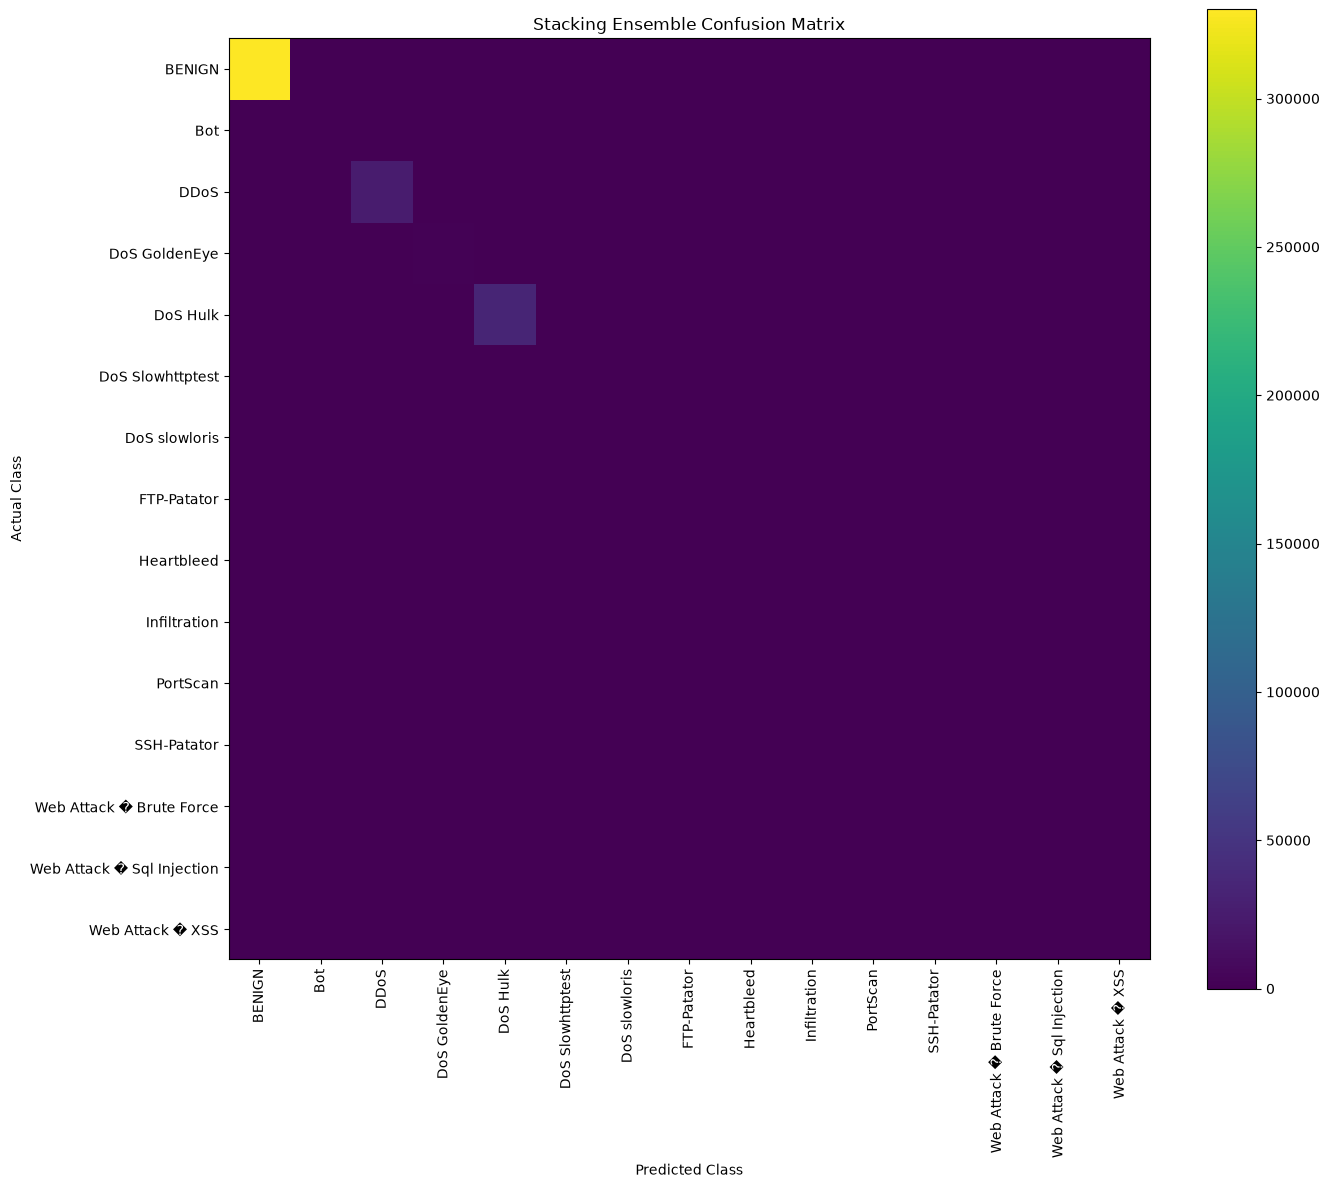


✓ Confusion matrix saved:
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/Stacking_Ensemble_Confusion_Matrix_Analysis.png


In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    stacking_pred,
    labels=np.arange(len(label_encoder.classes_))
)

class_names = label_encoder.classes_

plt.figure(figsize=(14, 12))

plt.imshow(cm)

plt.title(
    "Stacking Ensemble Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.colorbar()

plt.tight_layout()

cm_path = (
    FIGURE_DIR /
    "Stacking_Ensemble_Confusion_Matrix_Analysis.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("✓ Confusion matrix saved:")
print(cm_path)

In [32]:
print("=" * 70)
print("MINORITY CLASS MISCLASSIFICATION ANALYSIS")
print("=" * 70)

for i, class_name in enumerate(class_names):

    actual_total = cm[i].sum()
    correct = cm[i, i]
    incorrect = actual_total - correct

    recall = correct / actual_total if actual_total > 0 else 0

    print()
    print(f"Class: {class_name}")
    print(f"Actual samples : {actual_total}")
    print(f"Correct        : {correct}")
    print(f"Incorrect      : {incorrect}")
    print(f"Recall         : {recall:.4f}")

    if incorrect > 0:

        # Find where this class is being predicted
        wrong_predictions = []

        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                wrong_predictions.append(
                    (class_names[j], cm[i, j])
                )

        wrong_predictions.sort(
            key=lambda x: x[1],
            reverse=True
        )

        print("Most common wrong predictions:")

        for predicted_class, count in wrong_predictions[:5]:
            print(
                f"   → {predicted_class}: {count}"
            )

MINORITY CLASS MISCLASSIFICATION ANALYSIS

Class: BENIGN
Actual samples : 330906
Correct        : 330128
Incorrect      : 778
Recall         : 0.9976
Most common wrong predictions:
   → DoS Hulk: 234
   → Bot: 149
   → DoS GoldenEye: 111
   → Web Attack � XSS: 67
   → DoS Slowhttptest: 65

Class: Bot
Actual samples : 268
Correct        : 233
Incorrect      : 35
Recall         : 0.8694
Most common wrong predictions:
   → BENIGN: 35

Class: DDoS
Actual samples : 25603
Correct        : 25581
Incorrect      : 22
Recall         : 0.9991
Most common wrong predictions:
   → BENIGN: 21
   → Bot: 1

Class: DoS GoldenEye
Actual samples : 2056
Correct        : 2036
Incorrect      : 20
Recall         : 0.9903
Most common wrong predictions:
   → BENIGN: 16
   → DoS Slowhttptest: 2
   → DoS Hulk: 1
   → Web Attack � XSS: 1

Class: DoS Hulk
Actual samples : 34399
Correct        : 34105
Incorrect      : 294
Recall         : 0.9915
Most common wrong predictions:
   → BENIGN: 261
   → PortScan: 16
   → 

In [33]:
print("=" * 70)
print("WEB ATTACK FEATURE SEPARATION ANALYSIS")
print("=" * 70)

# Load training data
X_train = pd.read_parquet(
    DATASET_DIR / "X_train.parquet"
)

y_train = pd.read_parquet(
    DATASET_DIR / "y_train.parquet"
).squeeze()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

WEB ATTACK FEATURE SEPARATION ANALYSIS
X_train: (1591936, 30)
y_train: (1591936,)


In [36]:
print("=" * 70)
print("FIXING TRAINING DATA INDEX ALIGNMENT")
print("=" * 70)

# Reset indexes so X_train and y_train are aligned
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("Indexes aligned:",
      len(X_train) == len(y_train))

FIXING TRAINING DATA INDEX ALIGNMENT
X_train shape: (1591936, 30)
y_train shape: (1591936,)
Indexes aligned: True


In [37]:
print("=" * 70)
print("WEB ATTACK FEATURE SEPARATION ANALYSIS")
print("=" * 70)

analysis_labels = [0, 12, 13, 14]

feature_analysis = []

for label in analysis_labels:

    mask = y_train == label

    subset = X_train.loc[mask]

    print()
    print("=" * 70)
    print(f"CLASS: {label_encoder.classes_[label]}")
    print("Samples:", len(subset))
    print("=" * 70)

    feature_analysis.append(
        subset.mean()
    )

feature_means = pd.DataFrame(
    feature_analysis,
    index=[
        label_encoder.classes_[i]
        for i in analysis_labels
    ]
)

display(feature_means)

WEB ATTACK FEATURE SEPARATION ANALYSIS

CLASS: BENIGN
Samples: 1323620

CLASS: Web Attack � Brute Force
Samples: 1142

CLASS: Web Attack � Sql Injection
Samples: 16

CLASS: Web Attack � XSS
Samples: 522


,Fwd IAT Std,Bwd IAT Min,Flow IAT Min,Bwd Packet Length Std,Bwd Packet Length Mean,Avg Bwd Segment Size,Idle Min,Bwd Packet Length Max,Idle Mean,Packet Length Std,...,Flow IAT Std,PSH Flag Count,Active Mean,Fwd IAT Total,ACK Flag Count,Flow Duration,Bwd IAT Std,Subflow Fwd Bytes,Flow IAT Mean,Min Packet Length
BENIGN,1.712342e+06,1.540980e+06,177704.892988,169.148540,214.040571,214.040571,4.825522e+06,537.836260,5.142853e+06,199.229795,...,2.166897e+06,0.319337,104499.101104,1.494567e+07,0.149781,1.538363e+07,1.362607e+06,861.726565,1.223928e+06,23.63851
Web Attack � Brute Force,3.456318e+06,1.305727e+02,113.122592,34.849966,44.245161,44.245161,0.000000e+00,100.814361,0.000000e+00,32.817424,...,2.843491e+06,0.958844,0.000000,6.621775e+06,0.041156,6.884925e+06,1.643851e+05,2236.660245,1.637237e+06,0.00000
Web Attack � Sql Injection,3.027843e+05,3.992500e+02,42.875000,614.308015,350.284375,350.284375,0.000000e+00,1232.812500,0.000000e+00,407.639540,...,1.027243e+06,0.562500,0.000000,6.396801e+05,0.437500,2.828566e+06,1.236661e+06,315.875000,3.785386e+05,0.00000
Web Attack � XSS,3.555351e+06,1.153180e+02,126.151341,30.242263,59.099855,59.099855,0.000000e+00,114.204981,0.000000e+00,34.544278,...,2.915419e+06,0.965517,0.000000,6.805842e+06,0.034483,6.853944e+06,3.622838e+04,1306.061303,1.678871e+06,0.00000


In [38]:
print("=" * 70)
print("BRUTE FORCE vs XSS FEATURE DIFFERENCE")
print("=" * 70)

brute_mean = feature_means.loc[
    label_encoder.classes_[12]
]

xss_mean = feature_means.loc[
    label_encoder.classes_[14]
]

difference = (
    (brute_mean - xss_mean)
    .abs()
    .sort_values(ascending=False)
)

display(
    difference.head(15).to_frame(
        "Absolute Mean Difference"
    )
)

BRUTE FORCE vs XSS FEATURE DIFFERENCE


,Absolute Mean Difference
Fwd IAT Total,184067.435621
Bwd IAT Std,128156.766448
Fwd IAT Std,99033.622450
Fwd IAT Max,98778.176604
Flow IAT Max,79525.207172
Flow IAT Std,71928.392277
Flow IAT Mean,41634.117354
Flow Duration,30980.338503
Packet Length Variance,18941.365812
Subflow Fwd Bytes,930.598943


In [39]:
import numpy as np
import pandas as pd

print("=" * 70)
print("BRUTE FORCE vs XSS - FEATURE SEPARATION")
print("=" * 70)

BRUTE_FORCE = 12
XSS = 14

# Select the two classes
brute_mask = y_train == BRUTE_FORCE
xss_mask = y_train == XSS

brute_data = X_train.loc[brute_mask]
xss_data = X_train.loc[xss_mask]

results = []

for feature in X_train.columns:

    brute_values = brute_data[feature].values
    xss_values = xss_data[feature].values

    brute_mean = np.mean(brute_values)
    xss_mean = np.mean(xss_values)

    brute_std = np.std(brute_values)
    xss_std = np.std(xss_values)

    # Pooled standard deviation
    pooled_std = np.sqrt(
        (brute_std ** 2 + xss_std ** 2) / 2
    )

    if pooled_std != 0:
        cohens_d = abs(
            brute_mean - xss_mean
        ) / pooled_std
    else:
        cohens_d = 0

    results.append({
        "Feature": feature,
        "Brute_Force_Mean": brute_mean,
        "XSS_Mean": xss_mean,
        "Brute_Force_Std": brute_std,
        "XSS_Std": xss_std,
        "Cohens_d": cohens_d
    })

separation_df = pd.DataFrame(results)

separation_df = separation_df.sort_values(
    "Cohens_d",
    ascending=False
)

display(
    separation_df.head(15)
)

BRUTE FORCE vs XSS - FEATURE SEPARATION


,Feature,Brute_Force_Mean,XSS_Mean,Brute_Force_Std,XSS_Std,Cohens_d
26,Bwd IAT Std,1.643851e+05,3.622838e+04,6.002832e+05,2.301431e+05,0.281917
2,Flow IAT Min,1.131226e+02,1.261513e+02,3.723084e+01,5.897641e+01,0.264183
14,Packet Length Variance,1.328377e+04,3.222514e+04,8.461585e+04,1.899663e+05,0.128810
27,Subflow Fwd Bytes,2.236660e+03,1.306061e+03,9.550099e+03,7.766707e+03,0.106914
0,Fwd IAT Std,3.456318e+06,3.555351e+06,1.149970e+06,9.766012e+05,0.092831
20,Flow IAT Std,2.843491e+06,2.915419e+06,9.141783e+05,7.643707e+05,0.085364
28,Flow IAT Mean,1.637237e+06,1.678871e+06,5.397538e+05,4.533781e+05,0.083529
13,Fwd IAT Max,5.021426e+06,5.120204e+06,1.388616e+06,1.188250e+06,0.076435
11,Flow IAT Max,5.082901e+06,5.162426e+06,1.341839e+06,1.100620e+06,0.064804
5,Avg Bwd Segment Size,4.424516e+01,5.909985e+01,1.662761e+02,3.015041e+02,0.061013


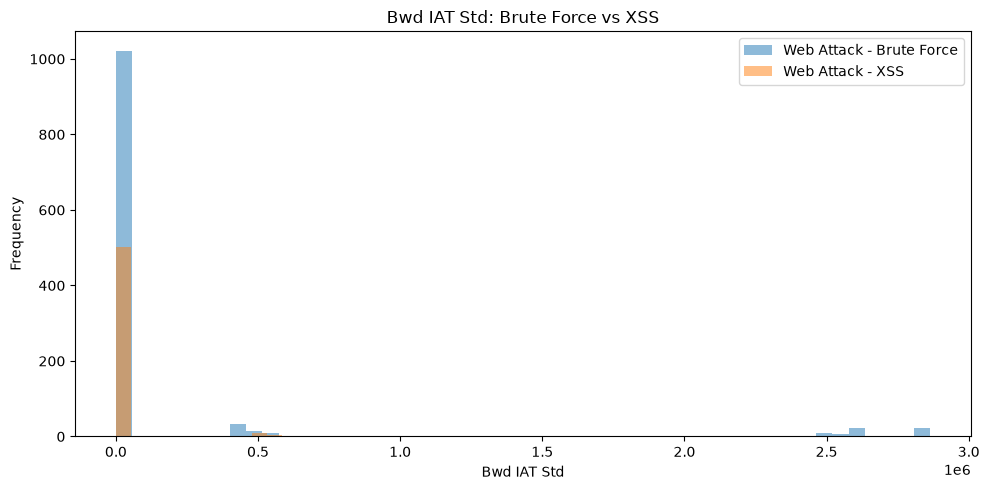

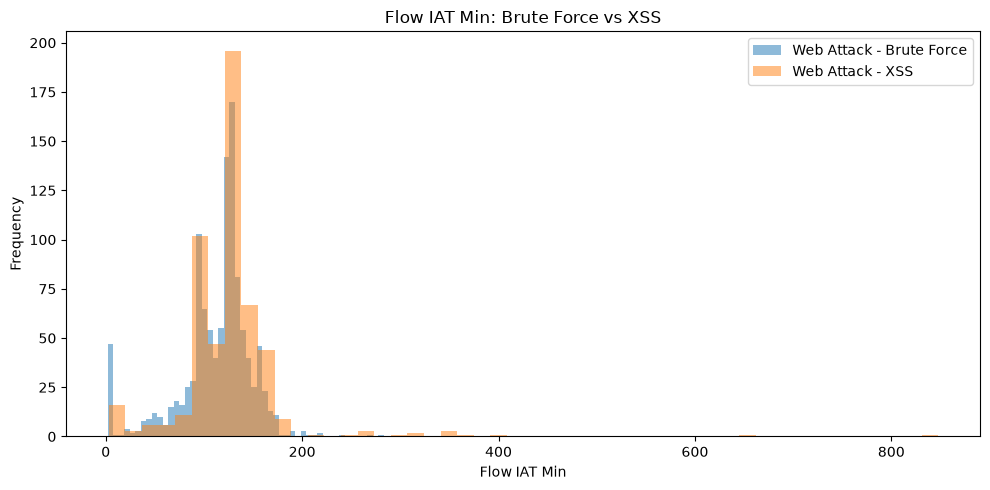

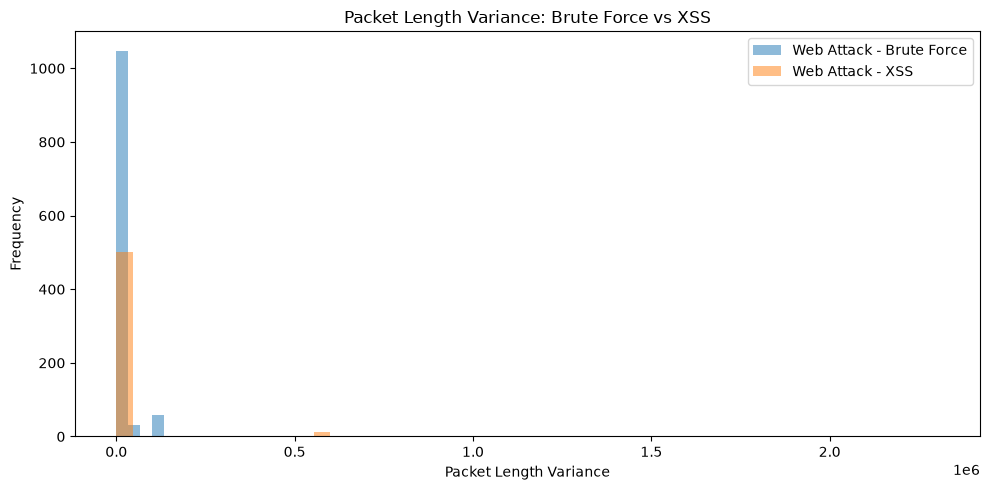

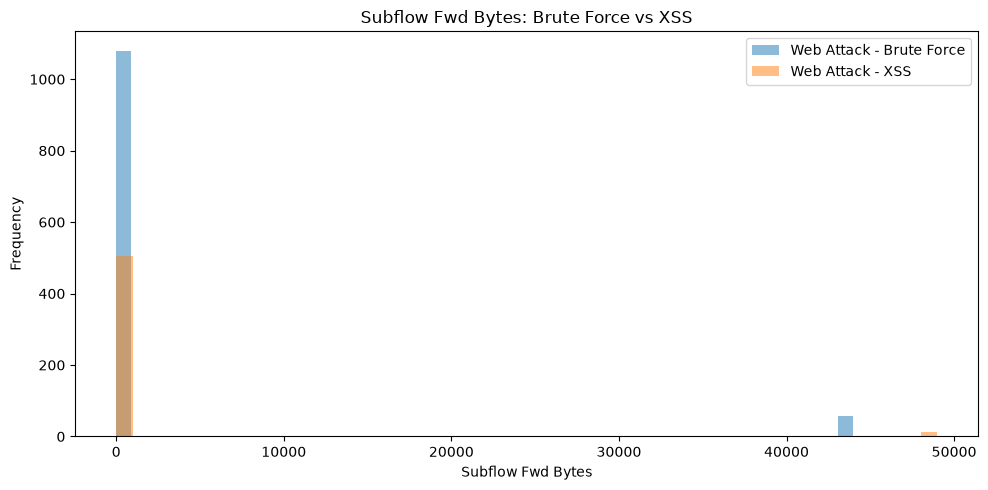

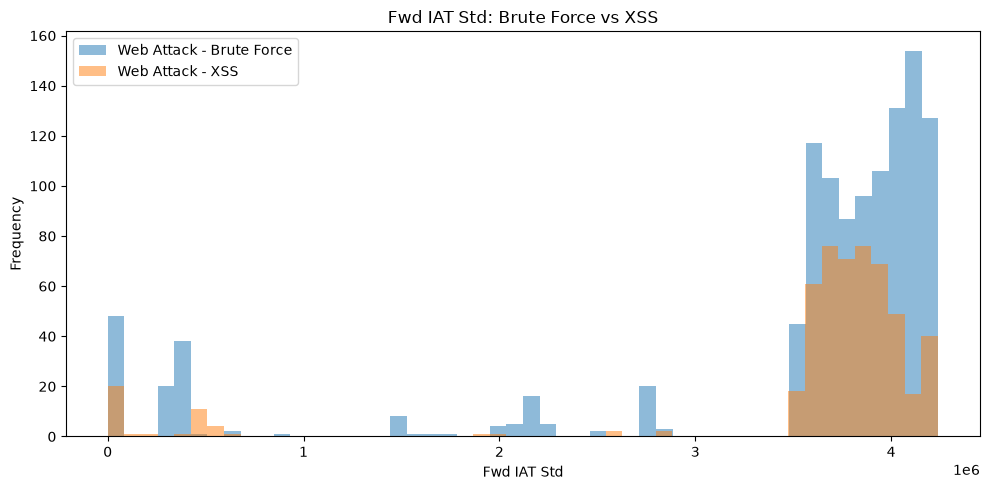

In [40]:
import matplotlib.pyplot as plt

top_features = separation_df.head(5)["Feature"].tolist()

for feature in top_features:

    plt.figure(figsize=(10, 5))

    plt.hist(
        brute_data[feature],
        bins=50,
        alpha=0.5,
        label="Web Attack - Brute Force"
    )

    plt.hist(
        xss_data[feature],
        bins=50,
        alpha=0.5,
        label="Web Attack - XSS"
    )

    plt.title(
        f"{feature}: Brute Force vs XSS"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()